In [123]:
!pip install tensorflow
!pip install seaborn

In [124]:
import pennylane as qp
from pennylane import numpy as np
from pennylane.templates import RandomLayers
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Setting of the main hyper-parameters of the model


In [125]:
n_epochs = 30   # Number of optimization epochs
n_layers = 30    # Number of random layers
n_train = 200    # Size of the train dataset
n_test = 200    # Size of the test dataset

SAVE_PATH = ""  # Data saving folder
PREPROCESS = True           # If False, skip quantum processing and load data from SAVE_PATH
np.random.seed(0)           # Seed for NumPy random number generator
tf.random.set_seed(0)       # Seed for TensorFlow random number generator

# Loading of the MNIST dataset
We import the MNIST dataset from Keras. To speedup the evaluation of this demo we use only a small number of training and test images. Obviously, better results are achievable when using the full dataset.




In [126]:
mnist_dataset = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist_dataset.load_data()

# Reduce dataset size
train_images = train_images[:n_train]
train_labels = train_labels[:n_train]
test_images = test_images[:n_test]
test_labels = test_labels[:n_test]

# Normalize pixel values within 0 and 1
train_images = train_images / 255
test_images = test_images / 255

# Add extra dimension for convolution channels
train_images = np.array(train_images[..., tf.newaxis], requires_grad=False)
test_images = np.array(test_images[..., tf.newaxis], requires_grad=False)

# Quantum circuit as a convolution kernel
---------------------------------------

We follow the scheme described in the introduction and represented in the figure at the top
of this demo.

We initialize a PennyLane ``default.qubit`` device, simulating a system of :math:`4` qubits.
The associated ``qnode`` represents the quantum circuit consisting of:

1. an embedding layer of local :math:`R_y` rotations (with angles scaled by a factor of :math:`\pi`);

2. a random circuit of ``n_layers``;

3. a final measurement in the computational basis, estimating :math:`4` expectation values.





In [127]:
dev = qp.device("default.qubit", wires=4)
# Random circuit parameters
rand_params = np.random.uniform(high=2 * np.pi, size=(n_layers, 4))

@qp.qnode(dev)
def circuit(phi):
    # Encoding of 4 classical input values
    for j in range(4):
        qp.RY(np.pi * phi[j], wires=j)

    # Random quantum circuit
    RandomLayers(rand_params, wires=list(range(4)))

    # Measurement producing 4 classical output values
    return [qp.expval(qp.PauliZ(j)) for j in range(4)]

# The next function defines the convolution scheme:

1. the image is divided into squares of :math:`2 \times 2` pixels;

2. each square is processed by the quantum circuit;

3. the :math:`4` expectation values are mapped into :math:`4` different
    channels of a single output pixel.

 .. note::
       This process halves the resolution of the input image. In the
       standard language of CNN, this would correspond to a convolution
       with a :math:`2 \times 2` *kernel* and a *stride* equal to :math:`2.`


In [128]:
def quanv(image):
    """Convolves the input image with many applications of the same quantum circuit."""
    out = np.zeros((14, 14, 4))

    # Loop over the coordinates of the top-left pixel of 2X2 squares
    for j in range(0, 28, 2):
        for k in range(0, 28, 2):
            # Process a squared 2x2 region of the image with a quantum circuit
            q_results = circuit(
                [
                    image[j, k, 0],
                    image[j, k + 1, 0],
                    image[j + 1, k, 0],
                    image[j + 1, k + 1, 0]
                ]
            )
            # Assign expectation values to different channels of the output pixel (j/2, k/2)
            for c in range(4):
                out[j // 2, k // 2, c] = q_results[c]
    return out

# Quantum pre-processing of the dataset


Since we are not going to train the quantum convolution layer, it is more
efficient to apply it as a "pre-processing" layer to all the images of our dataset.
Later an entirely classical model will be directly trained and tested on the
pre-processed dataset, avoiding unnecessary repetitions of quantum computations.

The pre-processed images will be saved in the folder ``SAVE_PATH``.
Once saved, they can be directly loaded by setting ``PREPROCESS = False``,
otherwise the quantum convolution is evaluated at each run of the code.


In [129]:
if PREPROCESS == False:
    q_train_images = []
    print("Quantum pre-processing of train images:")
    for idx, img in enumerate(train_images):
        print("{}/{}        ".format(idx + 1, n_train), end="\r")
        q_train_images.append(quanv(img))
    q_train_images = np.asarray(q_train_images)

    q_test_images = []
    print("\nQuantum pre-processing of test images:")
    for idx, img in enumerate(test_images):
        print("{}/{}        ".format(idx + 1, n_test), end="\r")
        q_test_images.append(quanv(img))
    q_test_images = np.asarray(q_test_images)

    # Save pre-processed images
    np.save(SAVE_PATH + "q_train_images.npy", q_train_images)
    np.save(SAVE_PATH + "q_test_images.npy", q_test_images)


# Load pre-processed images
q_train_images = np.load(SAVE_PATH + "q_train_images.npy")
q_test_images = np.load(SAVE_PATH + "q_test_images.npy")


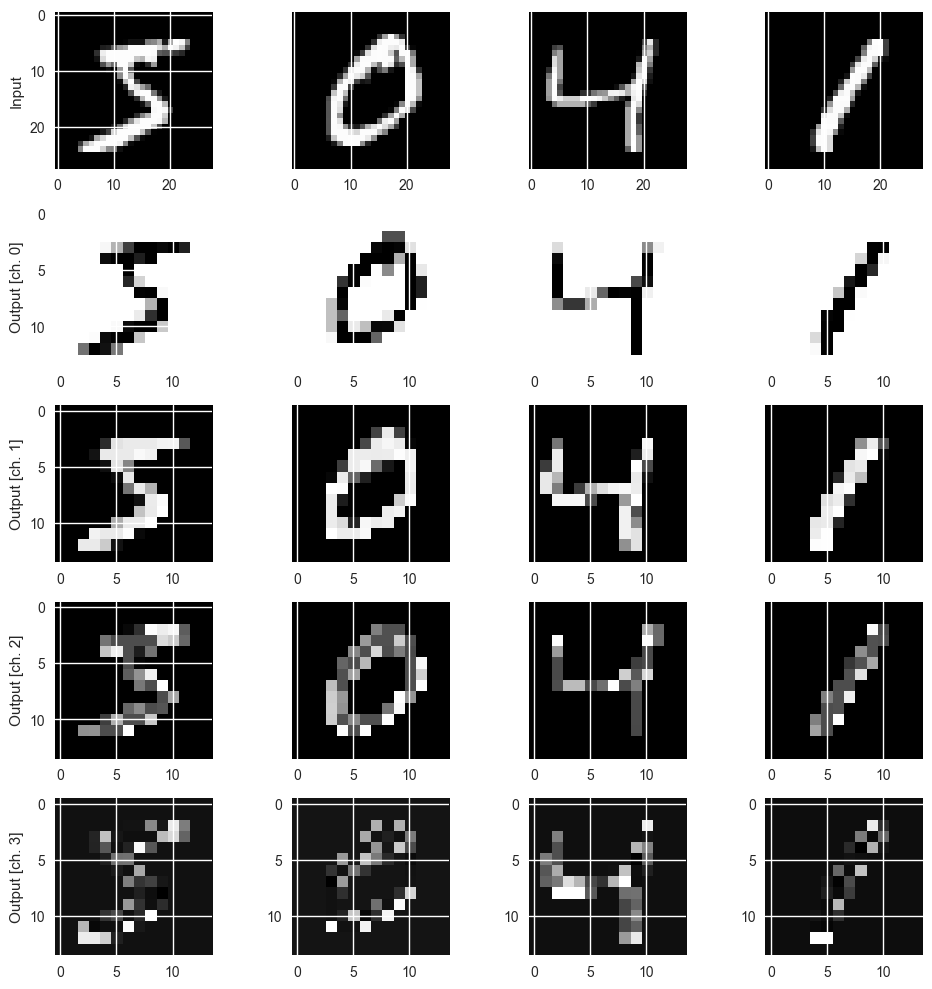

In [130]:
n_samples = 4
n_channels = 4
fig, axes = plt.subplots(1 + n_channels, n_samples, figsize=(10, 10))
for k in range(n_samples):
    axes[0, 0].set_ylabel("Input")
    if k != 0:
        axes[0, k].yaxis.set_visible(False)
    axes[0, k].imshow(train_images[k, :, :, 0], cmap="gray")

    # Plot all output channels
    for c in range(n_channels):
        axes[c + 1, 0].set_ylabel("Output [ch. {}]".format(c))
        if k != 0:
            axes[c, k].yaxis.set_visible(False)
        axes[c + 1, k].imshow(q_train_images[k, :, :, c], cmap="gray")

plt.tight_layout()
plt.show()

# Hybrid quantum-classical model
------------------------------

After the application of the quantum convolution layer we feed the resulting
features into a classical neural network that will be trained to classify
the :math:`10` different digits of the MNIST dataset.

We use a very simple model: just a fully connected layer with
10 output nodes with a final *softmax* activation function.

The model is compiled with a *stochastic-gradient-descent* optimizer,
and a *cross-entropy* loss function.


In [131]:
def MyModel():
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    model = keras.models.Sequential([
        keras.layers.Flatten(),
        keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer='adam',
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# Training

We first initialize an instance of the model, then we train and validate
it with the dataset that has been already pre-processed by a quantum convolution.

In [132]:
q_model = MyModel()

q_history = q_model.fit(
    q_train_images,
    train_labels,
    batch_size=4,
    epochs=n_epochs,
    verbose=2,
)

Epoch 1/30
50/50 - 0s - 6ms/step - accuracy: 0.2850 - loss: 2.1616
Epoch 2/30
50/50 - 0s - 691us/step - accuracy: 0.6850 - loss: 1.2702
Epoch 3/30
50/50 - 0s - 633us/step - accuracy: 0.8000 - loss: 0.8632
Epoch 4/30
50/50 - 0s - 610us/step - accuracy: 0.8600 - loss: 0.6482
Epoch 5/30
50/50 - 0s - 632us/step - accuracy: 0.8950 - loss: 0.5168
Epoch 6/30
50/50 - 0s - 695us/step - accuracy: 0.9250 - loss: 0.4258
Epoch 7/30
50/50 - 0s - 697us/step - accuracy: 0.9550 - loss: 0.3581
Epoch 8/30
50/50 - 0s - 719us/step - accuracy: 0.9650 - loss: 0.3052
Epoch 9/30
50/50 - 0s - 732us/step - accuracy: 0.9750 - loss: 0.2627
Epoch 10/30
50/50 - 0s - 724us/step - accuracy: 0.9850 - loss: 0.2278
Epoch 11/30
50/50 - 0s - 729us/step - accuracy: 0.9850 - loss: 0.1989
Epoch 12/30
50/50 - 0s - 748us/step - accuracy: 0.9950 - loss: 0.1749
Epoch 13/30
50/50 - 0s - 658us/step - accuracy: 0.9950 - loss: 0.1549
Epoch 14/30
50/50 - 0s - 637us/step - accuracy: 0.9950 - loss: 0.1381
Epoch 15/30
50/50 - 0s - 636us/

In order to compare the results achievable with and without the quantum convolution layer,
we initialize also a "classical" instance of the model that will be directly trained
and validated with the raw MNIST images (i.e., without quantum pre-processing).

In [133]:
c_model = MyModel()

c_history = c_model.fit(
    train_images,
    train_labels,
    batch_size=4,
    epochs=n_epochs,
    verbose=2,
)

Epoch 1/30
50/50 - 0s - 6ms/step - accuracy: 0.3500 - loss: 2.0154
Epoch 2/30
50/50 - 0s - 778us/step - accuracy: 0.8400 - loss: 1.2621
Epoch 3/30
50/50 - 0s - 1ms/step - accuracy: 0.8850 - loss: 0.8940
Epoch 4/30
50/50 - 0s - 1ms/step - accuracy: 0.8900 - loss: 0.6873
Epoch 5/30
50/50 - 0s - 680us/step - accuracy: 0.9200 - loss: 0.5569
Epoch 6/30
50/50 - 0s - 638us/step - accuracy: 0.9300 - loss: 0.4658
Epoch 7/30
50/50 - 0s - 655us/step - accuracy: 0.9350 - loss: 0.3977
Epoch 8/30
50/50 - 0s - 690us/step - accuracy: 0.9700 - loss: 0.3444
Epoch 9/30
50/50 - 0s - 626us/step - accuracy: 0.9800 - loss: 0.3015
Epoch 10/30
50/50 - 0s - 635us/step - accuracy: 0.9800 - loss: 0.2661
Epoch 11/30
50/50 - 0s - 647us/step - accuracy: 0.9800 - loss: 0.2366
Epoch 12/30
50/50 - 0s - 623us/step - accuracy: 0.9850 - loss: 0.2116
Epoch 13/30
50/50 - 0s - 625us/step - accuracy: 0.9850 - loss: 0.1904
Epoch 14/30
50/50 - 0s - 606us/step - accuracy: 0.9850 - loss: 0.1721
Epoch 15/30
50/50 - 0s - 617us/step

# Results

We can finally plot the test accuracy and the test loss with respect to the
number of training epochs.

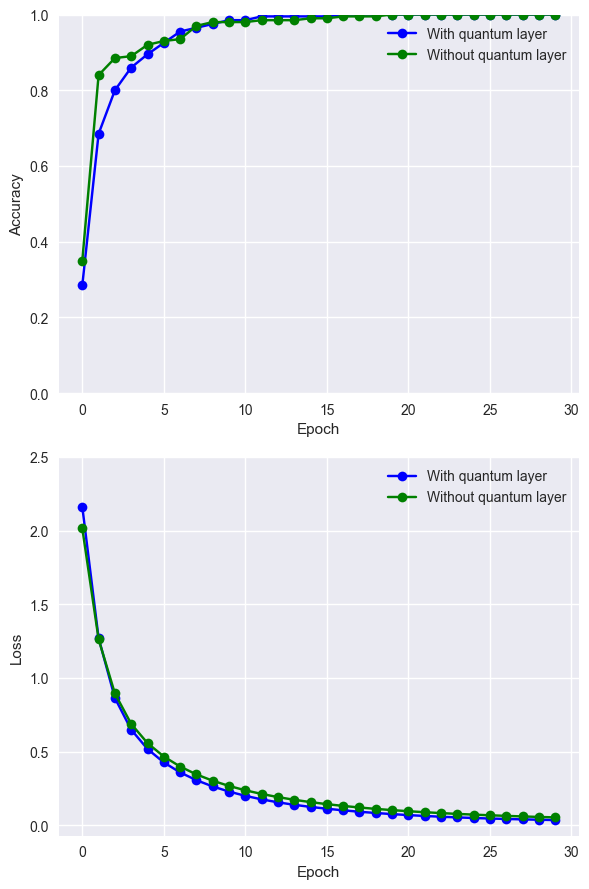

In [135]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 9))

ax1.plot(q_history.history["accuracy"], "-ob", label="With quantum layer")
ax1.plot(c_history.history["accuracy"], "-og", label="Without quantum layer")
ax1.set_ylabel("Accuracy")
ax1.set_ylim([0, 1])
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(q_history.history["loss"], "-ob", label="With quantum layer")
ax2.plot(c_history.history["loss"], "-og", label="Without quantum layer")
ax2.set_ylabel("Loss")
ax2.set_ylim(top=2.5)
ax2.set_xlabel("Epoch")
ax2.legend()
plt.tight_layout()
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


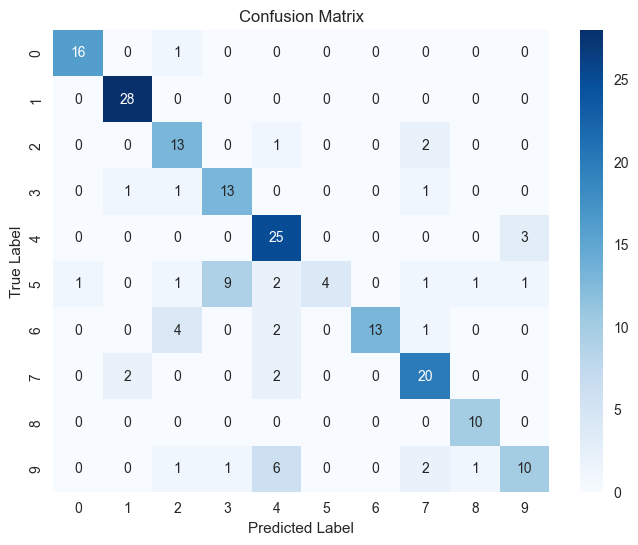

In [138]:
# 1. Get raw probability outputs from the model
y_pred_probs = q_model.predict(q_test_images)

# 2. Convert probabilities to integer class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Compute confusion matrix array
cm = confusion_matrix(test_labels, y_pred)

class_names = [str(i) for i in range(cm.shape[0])] 

# Plotting the visual heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names)

plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
